In [59]:
import numpy as np
import tensorflow as tf
from src.functions import functions
from src import utils
from src import hnn, sampling
from src.configs import CONFIGS

In [53]:
H = functions(dist_name="pmglmm")
H_B = functions(dist_name="pmglmmB")

pmgrad_fn_auto = utils.getpmgrad_fn(H_B)
config = CONFIGS["LHNN_pmglmm"]
config["num_hidden"] = 100

if "type_NN" not in config.keys() or config["type_NN"] == "HNN":
    model = hnn.HNN(config["input_dim"], config["num_hidden"], config["num_layers"], config["output_dim"], acti=config["acti"], baseline=config["baseline"], field_type=config["field_type"])
    model.load_weights("/home/ycui/Documents/TSRLproject_JPMorgan/models/LHNN_pmglmmB_sin.weights.h5")
elif config["type_NN"] == "PMHNN":
    model = hnn.PMHNN(config["inputdim_NN"], config["num_hidden"], config["num_layers"], acti=config["acti"])
    model.load_weights("/home/ycui/Documents/TSRLproject_JPMorgan/models/PMHNN_pmglmmB_new_sin.weights.h5")
else:
    raise ValueError(f"Invalid 'type_NN' value: {config.get('type_NN', None)}")

def pmgrad_fn_lhnn(theta, u, rho, p):
    cur_state = tf.reshape(tf.convert_to_tensor(np.concat([theta, u, rho, p],axis=0), dtype=tf.float32), [1,-1])
    grad = tf.reshape(model.get_gradient(cur_state),[-1]).numpy()[len(theta)+len(u):]
    return grad[0:len(theta)], grad[len(theta):]

In [54]:
rho = np.random.normal(size=13)
p = np.random.normal(size=len(utils.get_latent_u(500*128)))
grad_auto = pmgrad_fn_auto(utils.get_marginal_initial(), utils.get_latent_u(500*128), rho, p)[0]
grad_lhnn = pmgrad_fn_lhnn(utils.get_marginal_initial(), utils.get_latent_u(500*128), rho, p)[0]


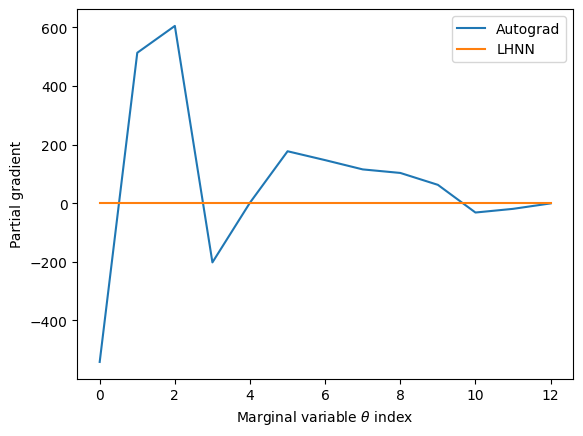

In [55]:
import matplotlib.pyplot as plt
plt.plot(grad_auto[:100], label="Autograd")
plt.plot(grad_lhnn[:100], label="LHNN")

plt.xlabel(r"Marginal variable $\theta$ index")
plt.ylabel("Partial gradient")
plt.legend()
plt.show()

In [56]:
rho = np.random.normal(size=13)
p = np.random.normal(size=len(utils.get_latent_u(500*128)))
states = utils.pmintegrator(utils.get_marginal_initial(), utils.get_latent_u(500*128), rho, p, pmgrad_fn_lhnn, 0.001, 100)
Hs = np.array([H(_state) for _state in states])

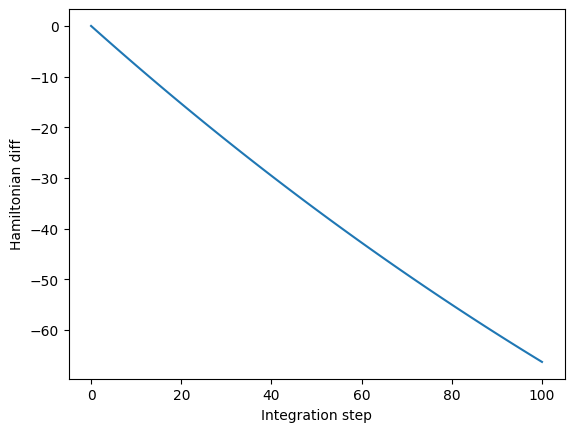

In [57]:
plt.plot(Hs[:]-Hs[0])
plt.xlabel("Integration step")
plt.ylabel("Hamiltonian diff")
plt.show()

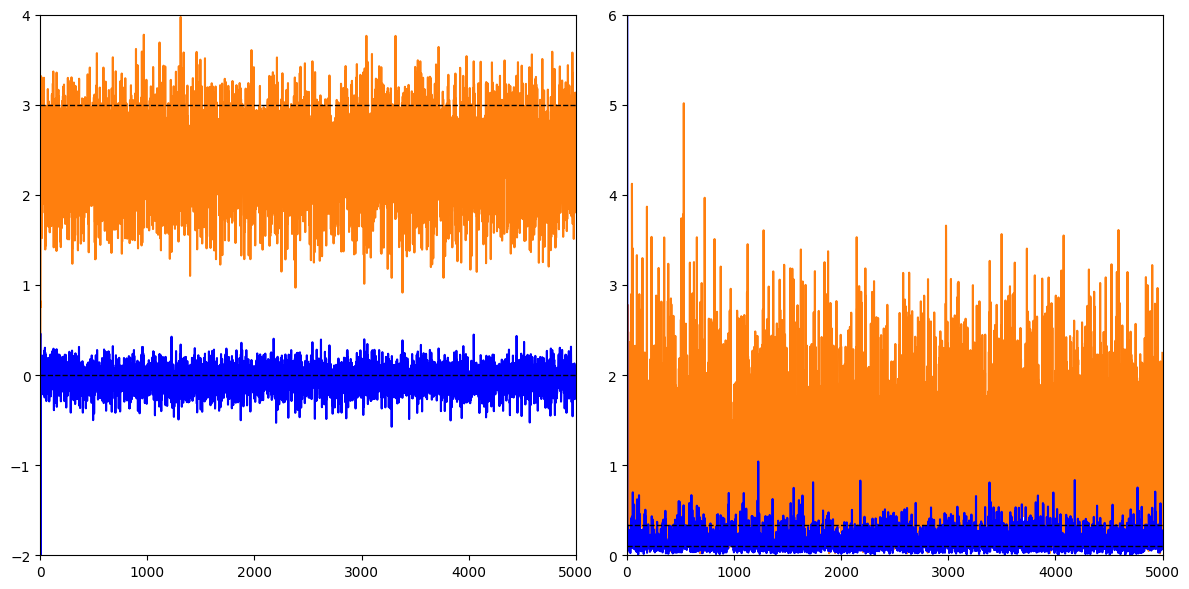

In [85]:
hmc_grad_pmglmm = sampling.sampling(config_name="LHNN_pmglmm", sampler_type="PMHMC", initial_state=np.concat([utils.get_marginal_initial(),utils.get_latent_u(500*128)]), dim_marginal=13, num_samples=100, burnin=1000, chains=1, epsilon=0.005, L=5,
         sample_path = "/home/ycui/Documents/TSRLproject_JPMorgan/samples/grad_hmc_pmglmm_priornarr_all_5000.pkl")


fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].plot(hmc_grad_pmglmm.samples[0][:,8], color='tab:orange')  # Orange line
axes[0].plot(hmc_grad_pmglmm.samples[0][:,9], color='blue')  # Blue line
axes[0].axhline(y=3, color='k', linestyle='--', linewidth=1)  # Dashed horizontal line
axes[0].axhline(y=0, color='k', linestyle='--', linewidth=1)  # Dashed horizontal line
axes[0].set_xlim(0, 5000) 
axes[0].set_ylim(-2, 4) 

axes[1].plot(np.exp(-hmc_grad_pmglmm.samples[0][:,10]), color='tab:orange')  # Orange line
axes[1].plot(np.exp(-hmc_grad_pmglmm.samples[0][:,11]), color='blue')  # Blue line
axes[1].axhline(y=1/10, color='k', linestyle='--', linewidth=1)  # Dashed horizontal line
axes[1].axhline(y=1/3, color='k', linestyle='--', linewidth=1)  # Dashed horizontal line
axes[1].set_xlim(0, 5000)
axes[1].set_ylim(0, 6)

plt.tight_layout()
plt.show()